# New science concepts and their papers — dataset standardisation demo (`data.py`)

This notebook is a lightly annotated version of the artifact's `data.py`. The artifact is an **outcome-blind pool of emerging scientific concepts**: noun phrases first used between 2005 and 2016, found by counting OpenAlex title and abstract surface forms. The sampling frame was frozen and sha256-hashed before any post-F+2 data was looked at. A stationary **reference arm** sits alongside it, and every concept comes with its **complete OpenAlex work list for 2000-2024**.

`data.py` turns the artifact's canonical files into the pipeline's `exp_sel_data_out` schema, **one example per data row, grouped by dataset**:

| dataset | source file | row = | output |
|---|---|---|---|
| `concept_pool_2005_2016` | `data_out.json` | concept | `oa_counts_by_year` + `work_ids` (JSON) |
| `concept_work_links` | `concept_work.parquet` | concept→work link | `match_evidence` |
| `openalex_works` | `works/*.parquet` | work | primary-topic subfield id |
| `subfield_year_totals` | `context/subfield_year_totals.json` | (variant, year, subfield) | count |
| `venue_habitat` | `context/venue_habitat.json` | venue | dominant subfield |

**What this demo runs.** The full sources take about 160 MB of parquet and JSON. For the demo, `mini_demo_data.json` holds a curated **100-concept subset of `concept_pool_2005_2016`**: 45 screen, 33 held-out and 22 reference concepts. The subset covers both retrieval routes, all F bands and volume terciles, and 20 `sense_check_fail` concepts. The notebook runs the `concept_pool_2005_2016` builder and the original part-splitting writer on this subset, then plots the concepts' OpenAlex trajectories. The other four builders are shown verbatim for reference. They need the artifact's parquet and context files, which are not shipped with the demo.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# orjson, loguru — NOT in Colab's pinned pre-installed list, always install
_pip('orjson==3.11.3', 'loguru==0.7.3')

# numpy, pandas, pyarrow, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports
This is the original `data.py` import block, unchanged. After it come the extra imports the notebook needs: `json` and `urllib` for loading the data, and `matplotlib` for the final plots.

In [2]:
import sys
from pathlib import Path

import orjson
import pandas as pd
import pyarrow.parquet as pq
from loguru import logger

# --- notebook-only additions ---
import json
from collections import Counter
import matplotlib.pyplot as plt

## Load the demo data
The demo data is fetched from the paper's GitHub repository. If that fails, the notebook falls back to a local `mini_demo_data.json`. The file has the same structure as the artifact's `data_out.json`: `{"metadata": ..., "datasets": [{"dataset": "concept_pool_2005_2016", "examples": [...]}]}`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_aMfESsKemlKH/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("concepts in demo file:", len(data["datasets"][0]["examples"]))

Outcome-blind pool of scientific concepts first used 2005-2016 (main arm) plus a stationary reference arm, with complete OpenAlex work lists 2000-2024. See README.md.
concepts in demo file: 100


## Configuration
These are the tunable parameters. In the original script, `ROOT` is the artifact directory and `PART_LIMIT` is 90 MB. When the serialised output is larger than `PART_LIMIT`, `write_parts` splits it into `full_data_out/full_data_out_N.json`.

* `N_CONCEPTS` sets how many concepts from the demo file are standardised. The file holds 100; the original run used all 206.
* `PART_LIMIT` is lowered so that the 100-concept demo takes the multi-part splitting path. Restore `90_000_000` for the original behaviour.
* `NAMES` lists the builders to run. The original runs all of `BEST5`, but the demo only has the concept-pool data.

In [5]:
N_CONCEPTS = 100 # concepts from mini_demo_data.json to standardise (demo max 100; original: all 206)
PART_LIMIT = 1_000_000    # bytes per output part (original: 90_000_000)
ROOT = Path("demo_out")   # output directory (original: Path(__file__).resolve().parent, the artifact dir)

BEST5 = ["concept_pool_2005_2016", "concept_work_links", "openalex_works", "subfield_year_totals", "venue_habitat"]
NAMES = ["concept_pool_2005_2016"]  # original: names = BEST5 (the other 4 need the artifact's parquet/context files)

ROOT.mkdir(exist_ok=True)

## Logging and a compact JSON helper
Unchanged from the original. Loguru logs to stdout and to `ROOT/logs/data.log`. `J` serialises an object to a compact JSON string using `orjson`. Every `input` and `output` field in the schema is a string, so structured values are stored as JSON text.

In [6]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

J = lambda o: orjson.dumps(o).decode()  # noqa: E731

## Dataset 1: `concept_pool_2005_2016`
`data_out.json` is already one row per concept. `ds_concept_pool` passes those examples through, and `concept_meta` indexes them by concept id so the link builder can copy each concept's `fold` onto its links.

Each concept example has:
* **input** (a JSON string): the phrase, its surface forms, the first-use year `F`, screen counts up to F+2, the early volume `V`, and the origin field and subfield.
* **output** (a JSON string): `oa_counts_by_year` for 2000-2024, `n_works` and the full `work_ids` list.
* **metadata**: the fold (screen, held-out concept or reference), F band, volume tercile, focal years, retrieval route, quality flags, and so on.

*Notebook change:* both functions read the loaded `data` instead of `ROOT / "data_out.json"`, and `ds_concept_pool` keeps only the first `N_CONCEPTS` concepts.

In [7]:
def concept_meta() -> dict:
    d = data  # original: orjson.loads((ROOT / "data_out.json").read_bytes())
    return {e["metadata_concept_id"]: e for e in d["datasets"][0]["examples"]}


def ds_concept_pool() -> list[dict]:
    d = data  # original: orjson.loads((ROOT / "data_out.json").read_bytes())
    return d["datasets"][0]["examples"][:N_CONCEPTS]

## Dataset 2: `concept_work_links`, and Dataset 3: `openalex_works`
These builders are verbatim and **not executed in the demo**, because they read `concept_work.parquet` (214,798 links) and `works/works_part_*.parquet` (208,374 works). Both use the same compact encoding. The `input` is a JSON *array* whose column order is given once in the top-level metadata (`feature_names`), not repeated as keys in every row, which keeps the export small.

In [8]:
LINK_FEATURES = ["concept_id", "work_id", "year"]


def ds_links(cm: dict) -> list[dict]:
    """input = JSON array ordered as LINK_FEATURES (names in top-level metadata to keep the file small)."""
    cw = pd.read_parquet(ROOT / "concept_work.parquet")
    out = []
    for i, r in enumerate(cw.itertuples(index=False)):
        c = cm[r.concept_id]
        out.append({"input": J([r.concept_id, int(r.work_id), int(r.year)]), "output": str(r.match_evidence),
                    "metadata_fold": c["metadata_fold"], "metadata_matched_form": r.matched_form,
                    "metadata_dup_group": None if pd.isna(r.dup_group) else int(r.dup_group)})
    return out


WORK_FEATURES = ["work_id", "publication_year", "type", "language", "doi_present", "s2_corpus_id", "primary_topic_id",
                 "topic_score", "topics_top3", "source_id", "source_type", "n_refs", "refs_in_corpus", "author_ids",
                 "keyword_idx", "concept_ids", "has_abstract", "abstract_n_tokens", "cited_by_count", "dup_group"]


def ds_works() -> list[dict]:
    """input = JSON array ordered as WORK_FEATURES; output = primary-topic subfield id (ASJC-style) or 'unknown'.
    Full referenced_works, institution_ids and keyword/concept scores stay in works/works_part_XX.parquet."""
    out = []
    cols = WORK_FEATURES + ["subfield_id", "field_id", "domain_id"]
    for p in sorted((ROOT / "works").glob("works_part_*.parquet")):
        for r in pq.read_table(p, columns=cols).to_pylist():
            if r["topic_score"] is not None:
                r["topic_score"] = round(float(r["topic_score"]), 4)
            sf = r["subfield_id"]
            out.append({"input": J([r[k] for k in WORK_FEATURES]), "output": str(sf) if sf is not None else "unknown",
                        "metadata_field_id": r["field_id"], "metadata_domain_id": r["domain_id"]})
    return out

## Dataset 4: `subfield_year_totals`, and Dataset 5: `venue_habitat`
These are also verbatim and **not executed in the demo**. They need `context/subfield_year_totals.json`, `taxonomy.json` and `context/venue_habitat.json`.
* **Dataset 4** gives the denominators used for per-10^4 normalisation. It has one row per (variant, year, subfield), with 4 variants: all, typed, has_abstract and has_references.
* **Dataset 5** gives the venue habitat. It has one row per venue, with the venue's subfield shares and its dominant subfield, plus megajournal and coverage flags.

In [9]:
def ds_denominators() -> list[dict]:
    d4 = orjson.loads((ROOT / "context" / "subfield_year_totals.json").read_bytes())
    tax = orjson.loads((ROOT / "taxonomy.json").read_bytes())
    out = []
    for v, years in d4["variants"].items():
        for y, t in sorted(years.items()):
            for sf, n in sorted(t["subfield"].items(), key=lambda x: int(x[0])):
                f = tax["subfield_field"].get(sf)
                out.append({"input": J({"variant": v, "year": int(y), "subfield_id": int(sf),
                                        "subfield_name": tax["subfields"].get(sf), "field_id": f,
                                        "domain_id": tax["field_domain"].get(str(f)) if f else None}),
                            "output": str(n), "metadata_level": "subfield", "metadata_task_type": "regression",
                            "metadata_year_total_with_topic": t["total_with_topic"], "metadata_year_unknown": t["unknown"]})
    return out


def ds_venues() -> list[dict]:
    d5 = orjson.loads((ROOT / "context" / "venue_habitat.json").read_bytes())
    out = []
    for v in d5["venues"]:
        inp = {k: v[k] for k in ["source_id", "issn_l", "display_name", "type", "host_org", "works_count",
                                 "max_works_per_year", "subfield_shares", "n_cpapers"]}
        out.append({"input": J(inp), "output": str(v["dominant_subfield"]) if v["dominant_subfield"] is not None else "unknown",
                    "metadata_dominant_share": v["dominant_share"], "metadata_megajournal": v["megajournal"],
                    "metadata_covered": v["covered"], "metadata_uncovered_reason": v["uncovered_reason"],
                    "metadata_task_type": "classification"})
    return out

## Top-level metadata and the size-limited writer
This cell is verbatim. `write_parts` first deletes any old outputs, then estimates the total serialised size. Below `PART_LIMIT`, it writes a single `full_data_out.json`. Otherwise it streams the examples into parts of at most `PART_LIMIT` bytes each, `full_data_out/full_data_out_N.json`. A dataset can be split across part boundaries, so a part may hold the tail of one dataset and the head of the next.

In [10]:
TOP_META = {
    "description": "Concept pool 2005-2016 artifact (see README.md). One example per data row, grouped by dataset.",
    "feature_names": {"concept_work_links": LINK_FEATURES, "openalex_works": WORK_FEATURES},
    "notes": {"openalex_works": "input is a JSON array in feature_names order; output = primary_topic subfield_id; full "
                                "refs/institutions/scores in works/works_part_XX.parquet",
              "concept_work_links": "input = [concept_id, work_id, year]; output = match_evidence; concept details in "
                                    "concept_pool_2005_2016"}}


def write_parts(datasets: list[dict]) -> None:
    for old in [ROOT / "full_data_out.json"] + sorted((ROOT / "full_data_out").glob("full_data_out_*.json")):
        old.unlink(missing_ok=True)
    total = sum(len(orjson.dumps(e)) + 1 for d in datasets for e in d["examples"])
    if total < PART_LIMIT:
        (ROOT / "full_data_out.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": datasets}))
        logger.info(f"wrote full_data_out.json ({total / 1e6:.1f} MB)")
        return
    (ROOT / "full_data_out").mkdir(exist_ok=True)
    parts, cur, size = [], [], 0
    for d in datasets:
        chunk = []
        for e in d["examples"]:
            b = len(orjson.dumps(e)) + 1
            if size + b > PART_LIMIT and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, size = [], [], 0
            chunk.append(e)
            size += b
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    for k, p in enumerate(parts, 1):
        (ROOT / "full_data_out" / f"full_data_out_{k}.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": p}))
    logger.info(f"wrote {len(parts)} parts to full_data_out/ ({total / 1e6:.1f} MB total)")

## Run the pipeline (`main`)
This is the original `main`. The only change is `names = NAMES` instead of `names = BEST5`, so only the builders whose inputs are present get run. Each builder's examples are wrapped as `{"dataset": name, "examples": [...]}` and handed to `write_parts`.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    cm = concept_meta()
    builders = {
        "concept_pool_2005_2016": ds_concept_pool,
        "concept_work_links": lambda: ds_links(cm),
        "openalex_works": ds_works,
        "subfield_year_totals": ds_denominators,
        "venue_habitat": ds_venues,
    }
    names = NAMES  # original: names = BEST5
    datasets = []
    for n in names:
        try:
            ex = builders[n]()
        except (FileNotFoundError, KeyError, ValueError) as e:
            logger.error(f"{n}: failed ({e})")
            raise
        logger.info(f"{n}: {len(ex)} examples")
        datasets.append({"dataset": n, "examples": ex})
    write_parts(datasets)


main()

03:23:08|INFO   |concept_pool_2005_2016: 100 examples


03:23:08|INFO   |wrote 2 parts to full_data_out/ (1.4 MB total)


## Results: read back the standardised output and look at the concepts
This cell reads back whatever `write_parts` produced, either one file or several parts. It then parses each example's JSON `input` and `output` and prints a per-concept table. The plots show:
1. the fold and retrieval-route composition of the exported pool;
2. OpenAlex works per year (2000-2024) for each concept, aligned at its first-use year `F`, with the main-arm median. Reference concepts have no `F`, because they are stationary controls that already existed before 2005, so they are shown in calendar time.

In [12]:
files = sorted((ROOT / "full_data_out").glob("full_data_out_*.json")) if (ROOT / "full_data_out").exists() else []
if (ROOT / "full_data_out.json").exists():
    files = [ROOT / "full_data_out.json"]
rows = []
for f in files:
    for ds in orjson.loads(f.read_bytes())["datasets"]:
        for e in ds["examples"]:
            inp, out = json.loads(e["input"]), json.loads(e["output"])
            rows.append({"file": f.name, "phrase": inp["phrase"], "fold": e["metadata_fold"],
                         "route": e["metadata_retrieval_route"], "F": inp.get("F"), "V": inp.get("early_volume_V"),
                         "origin_field": (inp.get("origin_field") or {}).get("name"), "n_works": out["n_works"],
                         "sense_fail": "sense_check_fail" in e["metadata_flags"],
                         "counts": {int(y): c for y, c in out["oa_counts_by_year"].items()}})
df = pd.DataFrame(rows)
df[["F", "V"]] = df[["F", "V"]].astype("Int64")  # reference concepts have no F / V
print(f"{len(files)} output file(s): {[f.name for f in files]}  |  {len(df)} concept examples")
print(df.groupby("file").size().rename("examples").to_string(), "\n")
pd.set_option("display.width", 160)
print(df.drop(columns="counts").sort_values(["fold", "F"]).head(30).to_string(index=False))
print("\nfold x route:\n", pd.crosstab(df["fold"], df["route"]).to_string())
print("\nn_works summary by fold:\n", df.groupby("fold")["n_works"].describe()[["count", "min", "50%", "max"]].to_string())

2 output file(s): ['full_data_out_1.json', 'full_data_out_2.json']  |  100 concept examples
file
full_data_out_1.json    67
full_data_out_2.json    33 

                file                             phrase            fold             route    F   V          origin_field  n_works  sense_fail
full_data_out_1.json       quark lepton complementarity heldout_concept A_openalex_native 2005  44 Physics and Astronomy      101       False
full_data_out_1.json                       egret excess heldout_concept        B_s2_index 2005  24 Physics and Astronomy       25       False
full_data_out_2.json                      gaussian mimo heldout_concept        B_s2_index 2005  26           Engineering      228       False
full_data_out_1.json              electrons in graphene heldout_concept        B_s2_index 2006  67     Materials Science      630       False
full_data_out_1.json                  quantum spin hall heldout_concept        B_s2_index 2006  83 Physics and Astronomy     2272       F

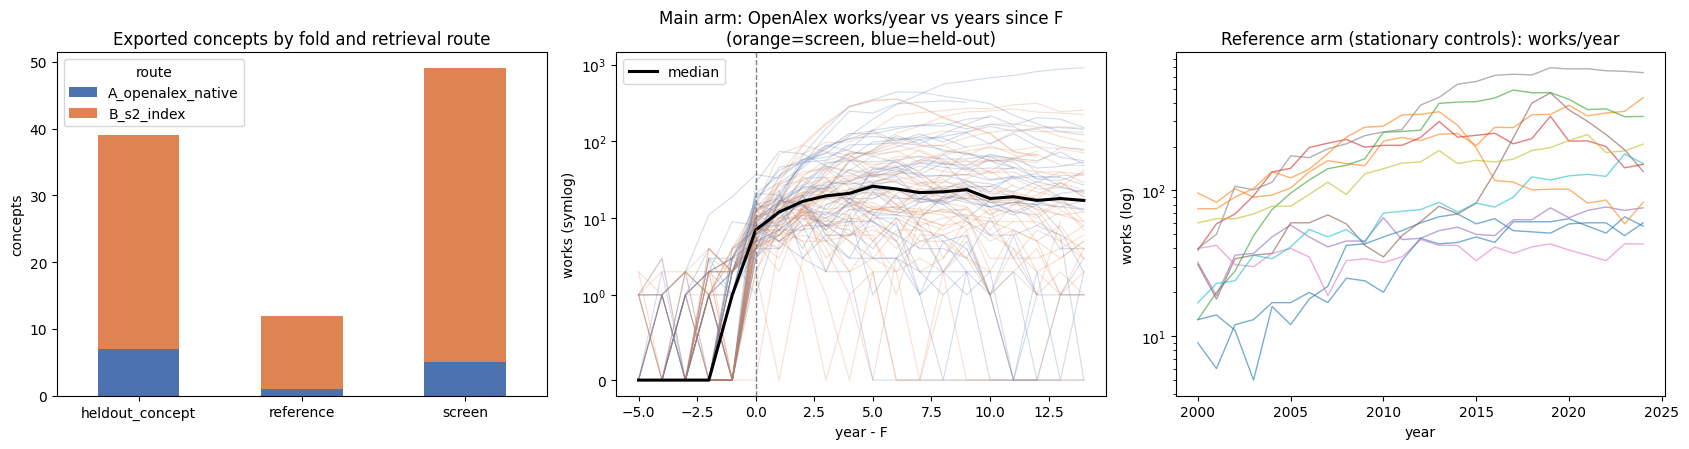

In [13]:
years = list(range(2000, 2025))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (1) composition
ct = pd.crosstab(df["fold"], df["route"])
ct.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#DD8452"], rot=0)
axes[0].set_title("Exported concepts by fold and retrieval route")
axes[0].set_ylabel("concepts"); axes[0].set_xlabel("")

# (2) main-arm trajectories aligned at first-use year F
main_df = df[df["fold"] != "reference"]
rel = range(-5, 15)
mat = []
for _, r in main_df.iterrows():
    traj = [r["counts"].get(r["F"] + k, float("nan")) if r["F"] else float("nan") for k in rel]
    mat.append(traj)
    axes[1].plot(list(rel), traj, color="#DD8452" if r["fold"] == "screen" else "#4C72B0", alpha=0.25, lw=0.8)
if mat:
    axes[1].plot(list(rel), pd.DataFrame(mat).median(axis=0, skipna=True).values, color="k", lw=2.2, label="median")
    axes[1].legend()
axes[1].set_yscale("symlog", linthresh=1)
axes[1].axvline(0, color="grey", ls="--", lw=1)
axes[1].set_title("Main arm: OpenAlex works/year vs years since F\n(orange=screen, blue=held-out)")
axes[1].set_xlabel("year - F"); axes[1].set_ylabel("works (symlog)")

# (3) reference arm in calendar time
for _, r in df[df["fold"] == "reference"].iterrows():
    axes[2].plot(years, [r["counts"].get(y, 0) for y in years], alpha=0.6, lw=1)
axes[2].set_yscale("log")
axes[2].set_title("Reference arm (stationary controls): works/year")
axes[2].set_xlabel("year"); axes[2].set_ylabel("works (log)")
plt.tight_layout(); plt.show()